# Phase 02 — Game-State Features and Four Model Tracks

This notebook reads the serialized Phase 01 cleaned event table, builds leakage-safe post-delivery game-state features, and writes four gender/innings-specific datasets with different first- and second-innings schemas.

Chronological train/validation/test assignment is deliberately deferred to Phase 04, where date-group boundaries and training-only transformations can be handled together.

In [1]:
from __future__ import annotations

import csv
import gzip
import json
from pathlib import Path

import pandas as pd
import yaml
from IPython.display import display

PROJECT_ROOT = next(
    (path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (path / 'data' / 'raw').exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Open this notebook inside the project repository.')

INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
PHASE_01_PATH = INTERIM_DIR / 'phase_01_cleaned_deliveries.csv.gz'
METRICS_PATH = PROJECT_ROOT / 'reports' / 'metrics' / 'phase_02_game_state_features.json'
PARAMS = yaml.safe_load((PROJECT_ROOT / 'params.yaml').read_text())
RECENT_EVENT_WINDOWS = PARAMS['features']['recent_event_windows']
assert RECENT_EVENT_WINDOWS == [10], 'Phase 02 currently defines one documented 10-event window'
if not PHASE_01_PATH.exists():
    raise FileNotFoundError('Run notebooks/01_data_audit_and_cleaning.ipynb first.')

COMMON_MODEL_FEATURES = [
    'innings_score',
    'innings_wickets',
    'wickets_remaining',
    'cumulative_innings_legal_balls',
    'legal_deliveries_remaining',
    'current_run_rate',
    'powerplay',
    'middle_overs',
    'death_overs',
    'runs_prev_10_events',
    'wickets_prev_10_events',
]
CHASE_MODEL_FEATURES = [
    'target_runs',
    'runs_to_win',
    'required_run_rate',
    'run_rate_differential',
    'target_progress',
]
FIRST_INNINGS_MODEL_FEATURES = COMMON_MODEL_FEATURES.copy()
SECOND_INNINGS_MODEL_FEATURES = COMMON_MODEL_FEATURES + CHASE_MODEL_FEATURES

AUDIT_EVENT_COLUMNS = [
    'match_id', 'source_row', 'event_sequence', 'match_date', 'gender', 'game',
    'venue', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
    'over', 'ball', 'match_innings', 'is_terminal_delivery', 'batting_team_win_match',
    'runs_batter', 'runs_extras', 'runs_total', 'current_event_wicket',
    'player_out', 'wicket_kind', 'wides', 'noballs', 'byes', 'legbyes', 'penalty',
    'legal_delivery',
]

print(f'Phase 01 input: {PHASE_01_PATH.relative_to(PROJECT_ROOT)}')

Phase 01 input: data/interim/phase_01_cleaned_deliveries.csv.gz


## 1. Load the audited Phase 01 event table

Phase 01 is the only source of truth for raw interpretation, match eligibility, innings segmentation, and source ordering.

In [2]:
cleaned = pd.read_csv(PHASE_01_PATH, parse_dates=['match_date'], low_memory=False)
required_columns = {
    'match_id', 'source_row', 'event_sequence', 'match_date', 'gender', 'game',
    'venue', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
    'over', 'ball', 'match_innings', 'innings_score', 'innings_wickets',
    'runs_batter', 'runs_extras', 'runs_total', 'is_wicket_bool', 'player_out',
    'wicket_kind', 'wides', 'noballs', 'byes', 'legbyes', 'penalty',
    'legal_delivery', 'match_winner',
}
assert required_columns.issubset(cleaned.columns)
assert cleaned['match_date'].notna().all()
assert cleaned.groupby('match_id')['match_innings'].nunique().eq(2).all()
assert cleaned.groupby('match_id')['source_row'].apply(lambda s: s.is_monotonic_increasing).all()

display(pd.DataFrame([
    {'metric': 'Phase 01 rows', 'value': len(cleaned)},
    {'metric': 'Phase 01 matches', 'value': cleaned['match_id'].nunique()},
    {'metric': 'Phase 01 columns', 'value': len(cleaned.columns)},
]))

,metric,value
0,Phase 01 rows,1156215
1,Phase 01 matches,4975
2,Phase 01 columns,40


## 2. Build post-delivery state features

The recent-form windows use the ten **recorded events preceding** the current row. Wides and no-balls therefore occupy event positions but do not advance the legal-ball clock. Current-event fields remain audit/attribution columns and are not model predictors.

In [3]:
def prior_event_rolling_sum(df: pd.DataFrame, value_column: str, window: int) -> pd.Series:
    groups = [df['match_id'], df['match_innings']]
    prior_values = df.groupby(groups, sort=False)[value_column].shift(1)
    rolled = prior_values.groupby(groups, sort=False).rolling(window, min_periods=1).sum()
    return rolled.reset_index(level=[0, 1], drop=True).fillna(0)


feature_table = cleaned.sort_values(
    ['match_id', 'match_innings', 'source_row'], kind='stable'
).reset_index(drop=True).copy()
innings_groups = [feature_table['match_id'], feature_table['match_innings']]
feature_table['cumulative_innings_legal_balls'] = (
    feature_table['legal_delivery'].groupby(innings_groups).cumsum()
)
feature_table['legal_deliveries_remaining'] = (
    120 - feature_table['cumulative_innings_legal_balls']
)
feature_table['wickets_remaining'] = (10 - feature_table['innings_wickets']).clip(lower=0)

balls_done = feature_table['cumulative_innings_legal_balls']
# A wide/no-ball before the first legal delivery is still inside the powerplay.
feature_table['powerplay'] = balls_done.between(0, 36).astype('int8')
feature_table['middle_overs'] = balls_done.between(37, 90).astype('int8')
feature_table['death_overs'] = balls_done.between(91, 120).astype('int8')

positive_legal_balls = balls_done.gt(0)
feature_table['current_run_rate'] = pd.Series(pd.NA, index=feature_table.index, dtype='Float64')
feature_table.loc[positive_legal_balls, 'current_run_rate'] = (
    6 * feature_table.loc[positive_legal_balls, 'innings_score']
    / feature_table.loc[positive_legal_balls, 'cumulative_innings_legal_balls']
)

first_scores = (
    feature_table.loc[feature_table['match_innings'].eq(1)]
    .groupby('match_id')['innings_score']
    .max()
)
second_innings = feature_table['match_innings'].eq(2)
feature_table['target_runs'] = pd.Series(pd.NA, index=feature_table.index, dtype='Float64')
feature_table.loc[second_innings, 'target_runs'] = (
    feature_table.loc[second_innings, 'match_id'].map(first_scores) + 1
)
raw_runs_to_win = feature_table['target_runs'] - feature_table['innings_score']
feature_table['runs_to_win'] = pd.Series(pd.NA, index=feature_table.index, dtype='Float64')
feature_table.loc[second_innings, 'runs_to_win'] = raw_runs_to_win.loc[second_innings].clip(lower=0)
active_chase = (
    second_innings
    & feature_table['legal_deliveries_remaining'].gt(0)
    & feature_table['runs_to_win'].gt(0)
)
feature_table['required_run_rate'] = pd.Series(pd.NA, index=feature_table.index, dtype='Float64')
feature_table.loc[active_chase, 'required_run_rate'] = (
    6 * feature_table.loc[active_chase, 'runs_to_win']
    / feature_table.loc[active_chase, 'legal_deliveries_remaining']
)
feature_table['run_rate_differential'] = pd.Series(pd.NA, index=feature_table.index, dtype='Float64')
feature_table.loc[active_chase, 'run_rate_differential'] = (
    feature_table.loc[active_chase, 'current_run_rate']
    - feature_table.loc[active_chase, 'required_run_rate']
)
feature_table['target_progress'] = pd.Series(pd.NA, index=feature_table.index, dtype='Float64')
feature_table.loc[second_innings, 'target_progress'] = (
    feature_table.loc[second_innings, 'innings_score']
    / feature_table.loc[second_innings, 'target_runs']
).clip(lower=0, upper=1)

feature_table['current_event_wicket'] = feature_table['is_wicket_bool'].astype('int8')
feature_table['runs_prev_10_events'] = prior_event_rolling_sum(
    feature_table, 'runs_total', RECENT_EVENT_WINDOWS[0]
)
feature_table['wickets_prev_10_events'] = prior_event_rolling_sum(
    feature_table, 'current_event_wicket', RECENT_EVENT_WINDOWS[0]
)
terminal_sequence = feature_table.groupby(
    ['match_id', 'match_innings']
)['event_sequence'].transform('max')
feature_table['is_terminal_delivery'] = feature_table['event_sequence'].eq(
    terminal_sequence
).astype('int8')
feature_table['batting_team_win_match'] = feature_table['batting_team'].eq(
    feature_table['match_winner']
).astype('int8')
feature_table = feature_table.sort_values('source_row', kind='stable').reset_index(drop=True)
second_innings = feature_table['match_innings'].eq(2)
balls_done = feature_table['cumulative_innings_legal_balls']

display(feature_table[
    ['gender', 'match_innings', *SECOND_INNINGS_MODEL_FEATURES, 'batting_team_win_match']
].head(10))

,gender,match_innings,innings_score,innings_wickets,wickets_remaining,cumulative_innings_legal_balls,legal_deliveries_remaining,current_run_rate,powerplay,middle_overs,death_overs,runs_prev_10_events,wickets_prev_10_events,target_runs,runs_to_win,required_run_rate,run_rate_differential,target_progress,batting_team_win_match
0,male,1,0,0,10,1,119,0.0,1,0,0,0.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0
1,male,1,0,0,10,2,118,0.0,1,0,0,0.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0
2,male,1,1,0,10,3,117,2.0,1,0,0,0.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0
3,male,1,3,0,10,4,116,4.5,1,0,0,1.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0
4,male,1,3,0,10,5,115,3.6,1,0,0,3.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0
5,male,1,6,0,10,6,114,6.0,1,0,0,3.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0
6,male,1,6,0,10,7,113,5.142857,1,0,0,6.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0
7,male,1,7,0,10,8,112,5.25,1,0,0,6.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0
8,male,1,7,0,10,9,111,4.666667,1,0,0,7.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0
9,male,1,7,0,10,10,110,4.2,1,0,0,7.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0


### Example of second-innings chase state

The example below is selected deterministically from long second innings near the median target. It illustrates how current and required run rates evolve; these chase quantities are undefined or unavailable in first-innings model schemas.

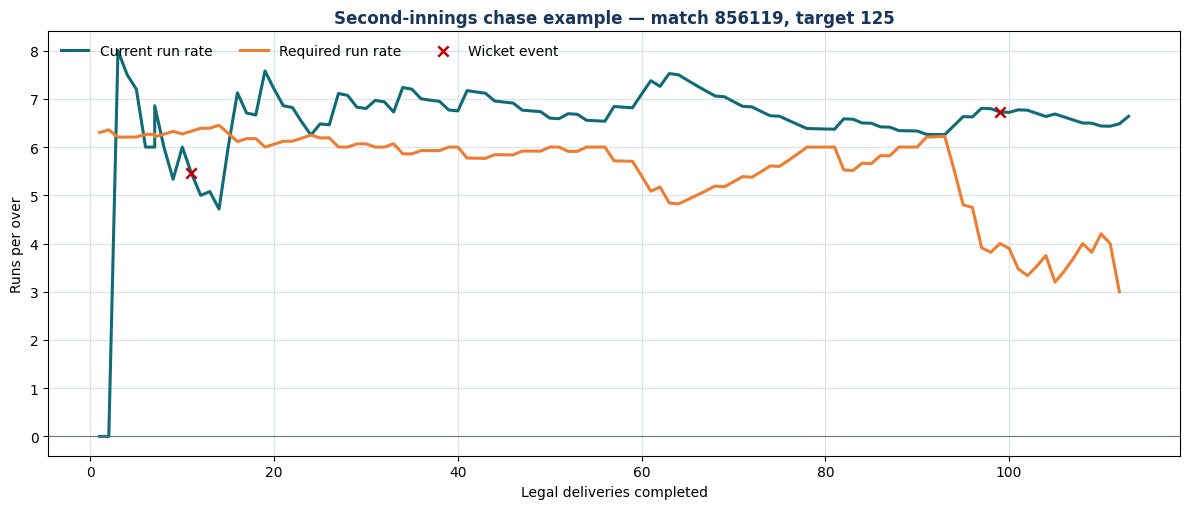

In [4]:
import matplotlib.pyplot as plt

NAVY = '#17365D'
TEAL = '#0F6B78'
ORANGE = '#ED7D31'
RED = '#C00000'
LIGHT_GRID = '#D9E2F3'

chase_rows = feature_table.loc[feature_table['match_innings'].eq(2)].copy()
chase_summary = (
    chase_rows.groupby('match_id', as_index=True)
    .agg(
        legal_balls=('cumulative_innings_legal_balls', 'max'),
        target_runs=('target_runs', 'first'),
        gender=('gender', 'first'),
        match_date=('match_date', 'first'),
        batting_team_win_match=('batting_team_win_match', 'first'),
    )
)
example_candidates = chase_summary.loc[
    chase_summary['batting_team_win_match'].eq(1)
    & chase_summary['legal_balls'].between(80, 115)
].copy()
if example_candidates.empty:
    example_candidates = chase_summary.loc[chase_summary['batting_team_win_match'].eq(1)].copy()
if example_candidates.empty:
    example_candidates = chase_summary.copy()
median_target = example_candidates['target_runs'].median()
example_match_id = (
    (example_candidates['target_runs'] - median_target).abs()
    .sort_values(kind='stable')
    .index[0]
)
example_chase = (
    chase_rows.loc[chase_rows['match_id'].eq(example_match_id)]
    .sort_values('source_row', kind='stable')
)

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.plot(
    example_chase['cumulative_innings_legal_balls'],
    example_chase['current_run_rate'],
    color=TEAL, linewidth=2.2, label='Current run rate',
)
ax.plot(
    example_chase['cumulative_innings_legal_balls'],
    example_chase['required_run_rate'],
    color=ORANGE, linewidth=2.2, label='Required run rate',
)
wickets = example_chase.loc[example_chase['current_event_wicket'].eq(1)]
ax.scatter(
    wickets['cumulative_innings_legal_balls'],
    wickets['current_run_rate'],
    color=RED, marker='x', s=55, linewidth=1.8, label='Wicket event', zorder=4,
)
ax.axhline(0, color='#6B7280', linewidth=0.8)
ax.set_xlabel('Legal deliveries completed')
ax.set_ylabel('Runs per over')
ax.set_title(
    f'Second-innings chase example — match {example_match_id}, '
    f'target {int(example_chase["target_runs"].iloc[0])}',
    fontweight='bold', color=NAVY,
)
ax.grid(color=LIGHT_GRID, linewidth=0.8)
ax.legend(frameon=False, ncol=3, loc='upper left')
fig.tight_layout()
plt.show()

## 3. Verify feature and leakage contracts

First-innings model schemas contain no chase columns. Gender, innings, identifiers, current-event fields, and result fields remain grouping/audit inputs rather than predictors.

In [5]:
for forbidden in {
    'match_id', 'match_innings', 'gender', 'match_winner', 'winning_outcome',
    'runs_total', 'current_event_wicket', 'player_out', 'wicket_kind',
}:
    assert forbidden not in FIRST_INNINGS_MODEL_FEATURES
    assert forbidden not in SECOND_INNINGS_MODEL_FEATURES
assert not set(CHASE_MODEL_FEATURES) & set(FIRST_INNINGS_MODEL_FEATURES)
assert len(AUDIT_EVENT_COLUMNS) == len(set(AUDIT_EVENT_COLUMNS))
assert len(FIRST_INNINGS_MODEL_FEATURES) == len(set(FIRST_INNINGS_MODEL_FEATURES))
assert len(SECOND_INNINGS_MODEL_FEATURES) == len(set(SECOND_INNINGS_MODEL_FEATURES))

assert feature_table['legal_deliveries_remaining'].ge(0).all()
assert feature_table['cumulative_innings_legal_balls'].le(120).all()
assert feature_table.loc[
    feature_table['cumulative_innings_legal_balls'].eq(0), 'powerplay'
].eq(1).all()
assert feature_table.loc[~second_innings, CHASE_MODEL_FEATURES].isna().all().all()
assert feature_table.loc[second_innings, 'target_runs'].notna().all()
assert feature_table.loc[second_innings, 'runs_to_win'].ge(0).all()
assert feature_table.loc[second_innings, 'target_progress'].between(0, 1).all()
assert feature_table['runs_prev_10_events'].ge(0).all()
assert feature_table['wickets_prev_10_events'].between(0, 10).all()

sample = pd.DataFrame({
    'match_id': [1, 1, 1, 1],
    'match_innings': [1, 1, 1, 1],
    'runs_total': [1, 2, 3, 4],
})
expected_prev_two = pd.Series([0.0, 1.0, 3.0, 5.0], name='runs_total')
actual_prev_two = prior_event_rolling_sum(sample, 'runs_total', 2).reset_index(drop=True)
pd.testing.assert_series_equal(actual_prev_two, expected_prev_two)

print('All in-memory feature and leakage checks passed.')

All in-memory feature and leakage checks passed.


## 4. Write four model-track datasets

Every output contains event/audit columns plus only the model features valid for that innings. No split labels are written in this phase.

In [6]:
track_specs = {
    'female_innings_1': ('female', 1, FIRST_INNINGS_MODEL_FEATURES),
    'female_innings_2': ('female', 2, SECOND_INNINGS_MODEL_FEATURES),
    'male_innings_1': ('male', 1, FIRST_INNINGS_MODEL_FEATURES),
    'male_innings_2': ('male', 2, SECOND_INNINGS_MODEL_FEATURES),
}
track_metrics = {}

for track_name, (gender, innings, model_features) in track_specs.items():
    track = feature_table.loc[
        feature_table['gender'].eq(gender) & feature_table['match_innings'].eq(innings)
    ].copy()
    output_columns = AUDIT_EVENT_COLUMNS + model_features
    assert len(output_columns) == len(set(output_columns)), f'Duplicate columns in {track_name}'
    if innings == 1:
        assert not set(CHASE_MODEL_FEATURES) & set(output_columns)
    output_path = INTERIM_DIR / f'phase_02_{track_name}.csv.gz'
    track[output_columns].to_csv(output_path, index=False, compression='gzip')

    with gzip.open(output_path, 'rt', newline='') as handle:
        reader = csv.reader(handle)
        serialized_header = next(reader)
        serialized_rows = sum(1 for _ in reader)
    assert serialized_header == output_columns
    assert len(serialized_header) == len(set(serialized_header))
    assert serialized_rows == len(track)

    track_metrics[track_name] = {
        'path': str(output_path.relative_to(PROJECT_ROOT)),
        'rows': int(len(track)),
        'matches': int(track['match_id'].nunique()),
        'columns': int(len(output_columns)),
        'date_min': track['match_date'].min().date().isoformat(),
        'date_max': track['match_date'].max().date().isoformat(),
        'outcome_prevalence': float(track['batting_team_win_match'].mean()),
        'model_feature_columns': model_features,
        'model_feature_nulls': {
            column: int(track[column].isna().sum()) for column in model_features
        },
    }
    print(f'{track_name}: {len(track):,} rows, {track["match_id"].nunique():,} matches')

female_innings_1: 235,716 rows, 1,871 matches


female_innings_2: 200,554 rows, 1,871 matches


male_innings_1: 382,777 rows, 3,104 matches


male_innings_2: 337,168 rows, 3,104 matches


### Predictor availability across the four tracks

The heatmap is an explicit schema check. Chase predictors are physically present only in second-innings tracks; grey cells mean the field is absent rather than null or imputed.

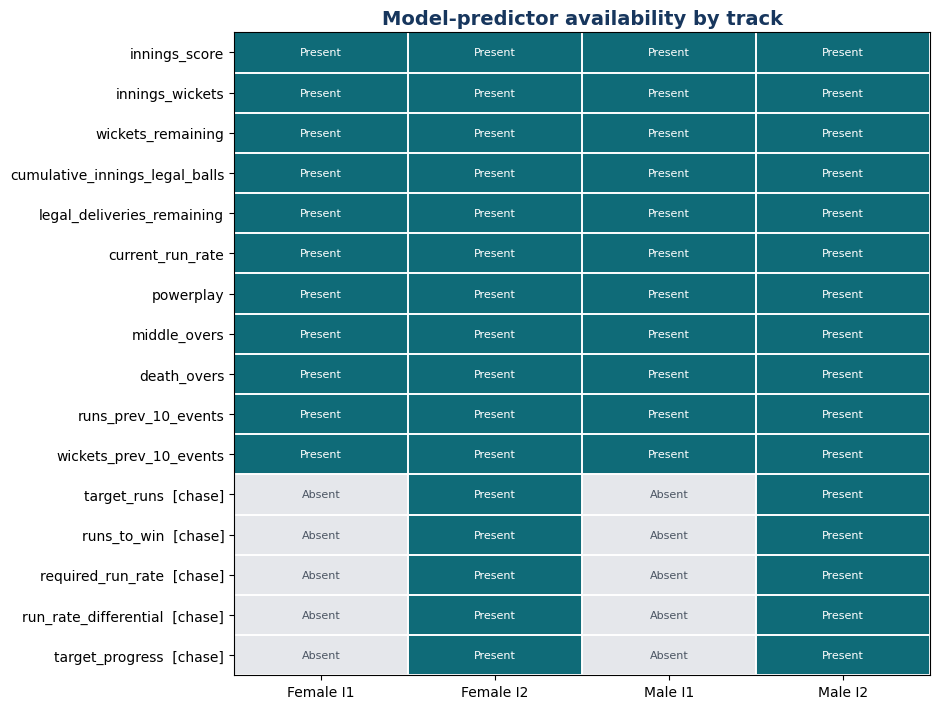

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

NAVY = '#17365D'
TEAL = '#0F6B78'
ABSENT = '#E5E7EB'

union_features = list(dict.fromkeys(FIRST_INNINGS_MODEL_FEATURES + SECOND_INNINGS_MODEL_FEATURES))
availability = pd.DataFrame(
    {
        track_name: [feature in model_features for feature in union_features]
        for track_name, (_, _, model_features) in track_specs.items()
    },
    index=union_features,
)
display_labels = [
    f'{feature}  [chase]' if feature in CHASE_MODEL_FEATURES else feature
    for feature in union_features
]
track_labels = ['Female I1', 'Female I2', 'Male I1', 'Male I2']

fig, ax = plt.subplots(figsize=(9.5, 7.2))
ax.imshow(availability.astype(int).to_numpy(), aspect='auto', cmap=ListedColormap([ABSENT, TEAL]), vmin=0, vmax=1)
ax.set_xticks(range(len(track_labels)), labels=track_labels)
ax.set_yticks(range(len(display_labels)), labels=display_labels)
ax.set_title('Model-predictor availability by track', fontsize=14, fontweight='bold', color=NAVY)
for row in range(availability.shape[0]):
    for column in range(availability.shape[1]):
        present = bool(availability.iloc[row, column])
        ax.text(column, row, 'Present' if present else 'Absent', ha='center', va='center', color='white' if present else '#4B5563', fontsize=8)
ax.set_xticks(np.arange(-0.5, availability.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, availability.shape[0], 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.4)
ax.tick_params(which='minor', bottom=False, left=False)
fig.tight_layout()
plt.show()

## 5. Save compact Phase 02 metrics

In [8]:
phase_02_metrics = {
    'report_version': 2,
    'source': {
        'path': str(PHASE_01_PATH.relative_to(PROJECT_ROOT)),
        'rows': int(len(cleaned)),
        'matches': int(cleaned['match_id'].nunique()),
    },
    'model_feature_columns_by_innings': {
        '1': FIRST_INNINGS_MODEL_FEATURES,
        '2': SECOND_INNINGS_MODEL_FEATURES,
    },
    'tracks': track_metrics,
    'quality_checks': {
        'first_innings_chase_predictor_count': int(
            len(set(CHASE_MODEL_FEATURES) & set(FIRST_INNINGS_MODEL_FEATURES))
        ),
        'forbidden_predictor_count': int(len(
            {'match_id', 'match_innings', 'gender', 'match_winner', 'winning_outcome',
             'runs_total', 'current_event_wicket'}
            & set(FIRST_INNINGS_MODEL_FEATURES + SECOND_INNINGS_MODEL_FEATURES)
        )),
        'zero_legal_ball_rows_outside_powerplay': int(
            (feature_table.loc[balls_done.eq(0), 'powerplay'] != 1).sum()
        ),
        'target_progress_out_of_range_rows': int(
            (~feature_table.loc[second_innings, 'target_progress'].between(0, 1)).sum()
        ),
        'duplicate_output_header_count': 0,
        'max_legal_balls': int(balls_done.max()),
        'min_legal_balls_remaining': int(feature_table['legal_deliveries_remaining'].min()),
    },
}
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.write_text(json.dumps(phase_02_metrics, indent=2, sort_keys=True) + '\n')

display(pd.DataFrame([
    {'track': name, 'rows': values['rows'], 'matches': values['matches'], 'columns': values['columns']}
    for name, values in track_metrics.items()
]))
print(f'Phase 02 metrics: {METRICS_PATH.relative_to(PROJECT_ROOT)}')

,track,rows,matches,columns
0,female_innings_1,235716,1871,40
1,female_innings_2,200554,1871,45
2,male_innings_1,382777,3104,40
3,male_innings_2,337168,3104,45


Phase 02 metrics: reports/metrics/phase_02_game_state_features.json


## Phase-02 conclusion

The project now has four serialized, schema-validated post-delivery game-state datasets. Phase 03 may add strictly prior-date player, team, and venue histories. Phase 04 must create date-grouped chronological splits and add explicit pre-innings states before model training.